In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

In [12]:
df = pd.read_csv(
    "C:/Users/aa122/Downloads/Sample - Superstore.csv",
    encoding='latin1'
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [14]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [15]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [16]:
df = df[['Order Date', 'Sales']]

df.columns = ['ds', 'y']

df.head()

,ds,y
0,11-08-2016,261.9600
1,11-08-2016,731.9400
2,06-12-2016,14.6200
3,10-11-2015,957.5775
4,10-11-2015,22.3680


In [17]:
df['ds'] = pd.to_datetime(df['ds'], format='mixed')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      9994 non-null   datetime64[ns]
 1   y       9994 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 156.3 KB


In [18]:
df.isnull().sum()

ds    0
y     0
dtype: int64

In [19]:
df.dropna(inplace = True)

In [20]:
# Aggregate Daily Sales

daily_sales = df.groupby('ds')['y'].sum().reset_index()

daily_sales.head()

,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


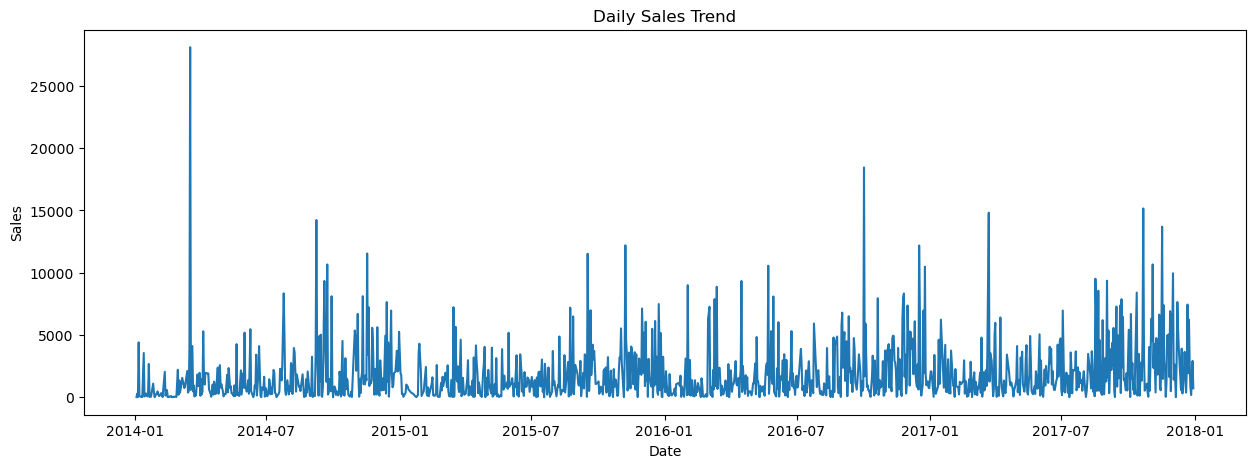

In [21]:
# Data Visualization (EDA)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(daily_sales['ds'], daily_sales['y'])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

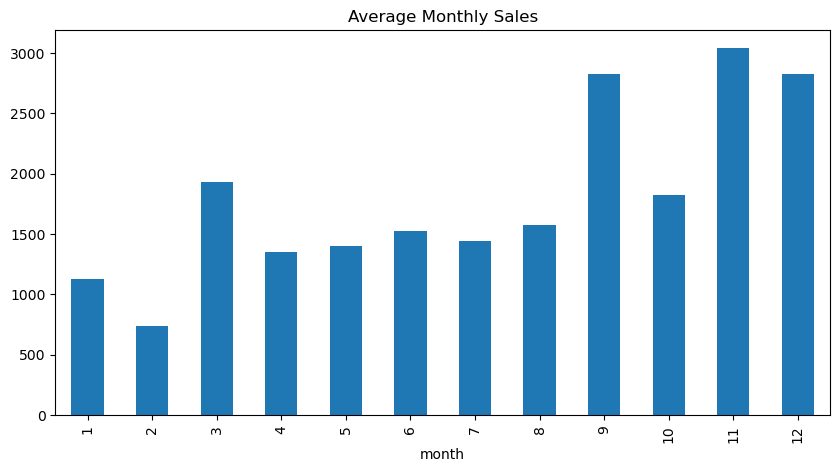

In [22]:
# Monthly Trend

daily_sales['month'] = daily_sales['ds'].dt.month

monthly = daily_sales.groupby('month')['y'].mean()

monthly.plot(kind='bar',figsize=(10,5))
plt.title('Average Monthly Sales')
plt.show()










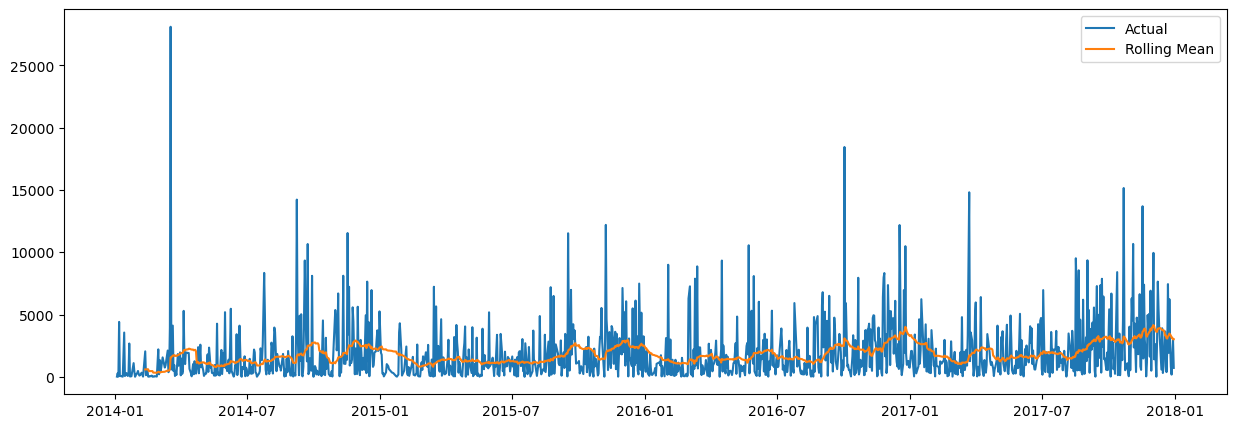

In [23]:
# Rolling Mean

daily_sales['rolling_mean'] = daily_sales['y'].rolling(window=30).mean()

plt.figure(figsize=(15,5))

plt.plot(daily_sales['ds'], daily_sales['y'], label='Actual')
plt.plot(daily_sales['ds'], daily_sales['rolling_mean'], label='Rolling Mean')

plt.legend()
plt.show()

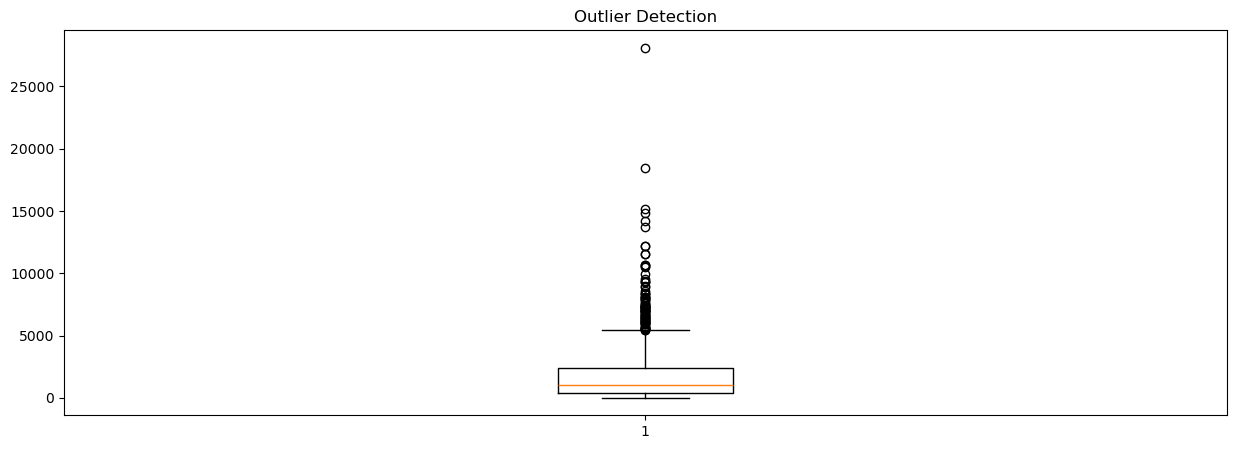

In [24]:
# Detect Outliers


plt.figure(figsize=(15,5))

plt.boxplot(daily_sales['y'])

plt.title("Outlier Detection")
plt.show()

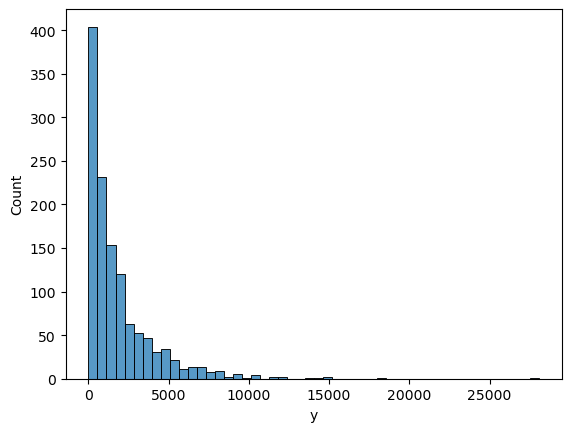

In [25]:
# Distribution Plot

sns.histplot(daily_sales['y'], bins = 50)

plt.show()

In [26]:
# Create Model

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True

)

In [27]:
# Train Model

model.fit(daily_sales)

09:13:47 - cmdstanpy - INFO - Chain [1] start processing
09:13:48 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
# Create Future Dates

future = model.make_future_dataframe(periods=365)

In [29]:
# Predict

forecast = model.predict(future)

In [30]:
# View Forecast

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1597,2018-12-26,2151.039894,-524.042047,4980.709778
1598,2018-12-27,3253.789434,571.740208,6158.098711
1599,2018-12-28,3415.874298,451.964150,6170.994068
1600,2018-12-29,2913.015829,218.326492,5525.672148
1601,2018-12-30,2987.364501,290.441362,5685.835702


In [31]:

# Cross Validation

from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics

In [32]:
df_cv = cross_validation(
    model,
    initial='365 days',
    period='90 days',
    horizon='90 days'
)

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/12 [00:00<?, ?it/s]

09:13:49 - cmdstanpy - INFO - Chain [1] start processing
09:13:50 - cmdstanpy - INFO - Chain [1] done processing
09:13:50 - cmdstanpy - INFO - Chain [1] start processing
09:13:50 - cmdstanpy - INFO - Chain [1] done processing
09:13:50 - cmdstanpy - INFO - Chain [1] start processing
09:13:50 - cmdstanpy - INFO - Chain [1] done processing
09:13:50 - cmdstanpy - INFO - Chain [1] start processing
09:13:50 - cmdstanpy - INFO - Chain [1] done processing
09:13:50 - cmdstanpy - INFO - Chain [1] start processing
09:13:51 - cmdstanpy - INFO - Chain [1] done processing
09:13:51 - cmdstanpy - INFO - Chain [1] start processing
09:13:51 - cmdstanpy - INFO - Chain [1] done processing
09:13:51 - cmdstanpy - INFO - Chain [1] start processing
09:13:51 - cmdstanpy - INFO - Chain [1] done processing
09:13:51 - cmdstanpy - INFO - Chain [1] start processing
09:13:51 - cmdstanpy - INFO - Chain [1] done processing
09:13:52 - cmdstanpy - INFO - Chain [1] start processing
09:13:52 - cmdstanpy - INFO - Chain [1]

In [33]:
df_p = performance_metrics(df_cv)

df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,10 days,2.507566e+06,1583.529643,1056.778907,15.667088,0.785274,0.896804,0.937888
1,11 days,2.503604e+06,1582.278000,1067.734684,15.353032,0.705191,0.882335,0.945652
2,12 days,3.152162e+06,1775.433025,1152.396612,14.636282,0.729861,0.873802,0.923913
3,13 days,3.150485e+06,1774.960503,1188.006420,14.742052,0.705191,0.889205,0.929348
4,14 days,2.998101e+06,1731.502473,1150.974791,10.949769,0.682236,0.878029,0.934783


In [34]:
train = daily_sales.iloc[:-90]
test = daily_sales.iloc[-90:]

In [35]:
model = Prophet()

model.fit(train)

09:13:53 - cmdstanpy - INFO - Chain [1] start processing
09:13:53 - cmdstanpy - INFO - Chain [1] done processing


In [37]:
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

In [38]:
pred = forecast[['ds', 'yhat']].tail(90)

final_df = test.merge(pred, on='ds')

In [39]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(final_df['y'], final_df['yhat'])

print("MAE:", mae)

MAE: 2112.173548565378


In [40]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(
    final_df['y'],
    final_df['yhat']
))

print("RMSE:", rmse)

RMSE: 2941.737072253721


In [41]:
mape = np.mean(
    np.abs((final_df['y'] - final_df['yhat']) / final_df['y'])
) * 100

print("MAPE:", mape)

MAPE: 609.2437753533527


In [43]:
final_df['residual'] = final_df['y'] - final_df['yhat']

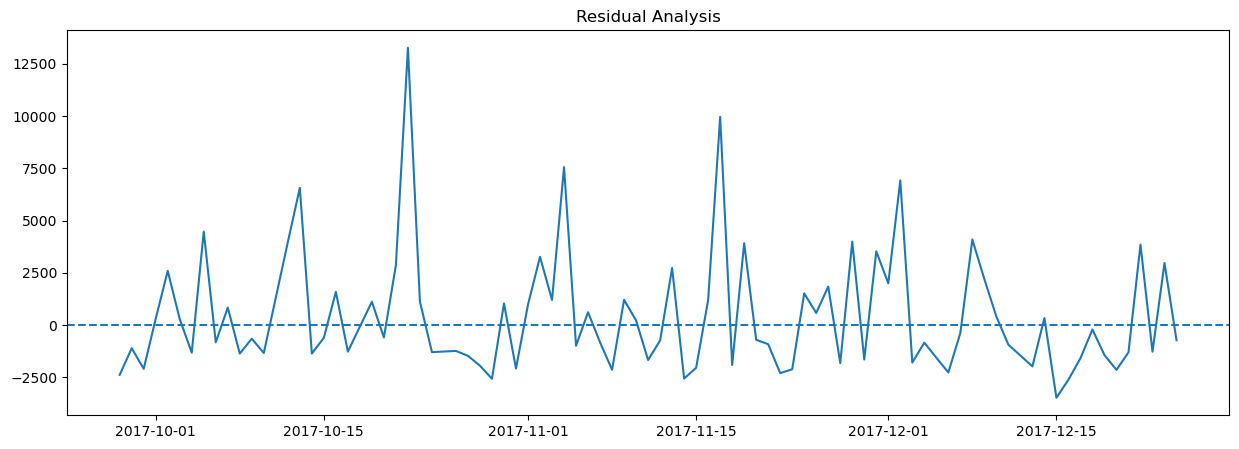

In [45]:
plt.figure(figsize=(15,5))

plt.plot(final_df['ds'], final_df['residual'])

plt.axhline(0, linestyle='--')

plt.title("Residual Analysis")

plt.show()

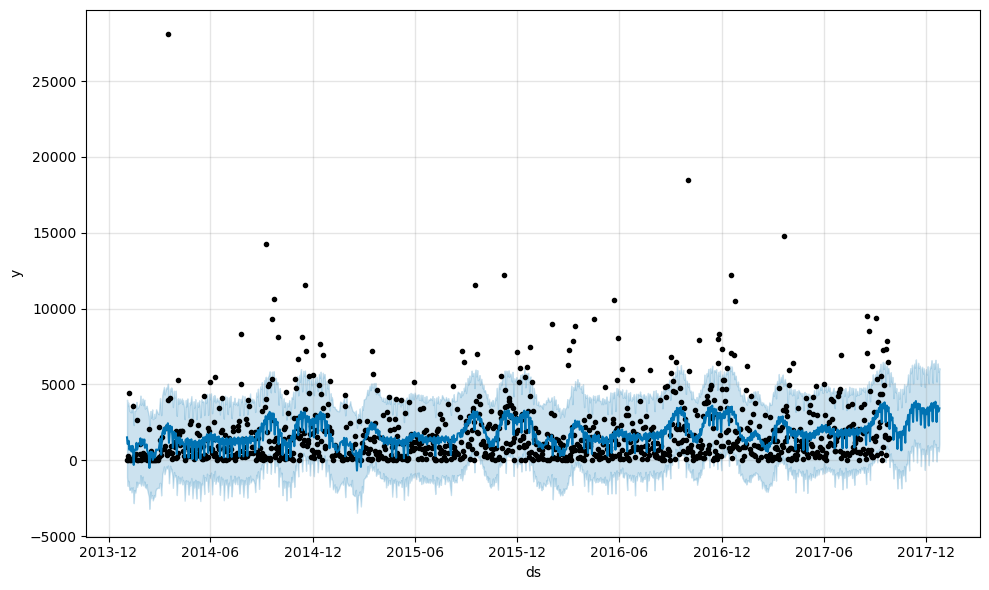

In [46]:
fig1 = model.plot(forecast)
plt.show()

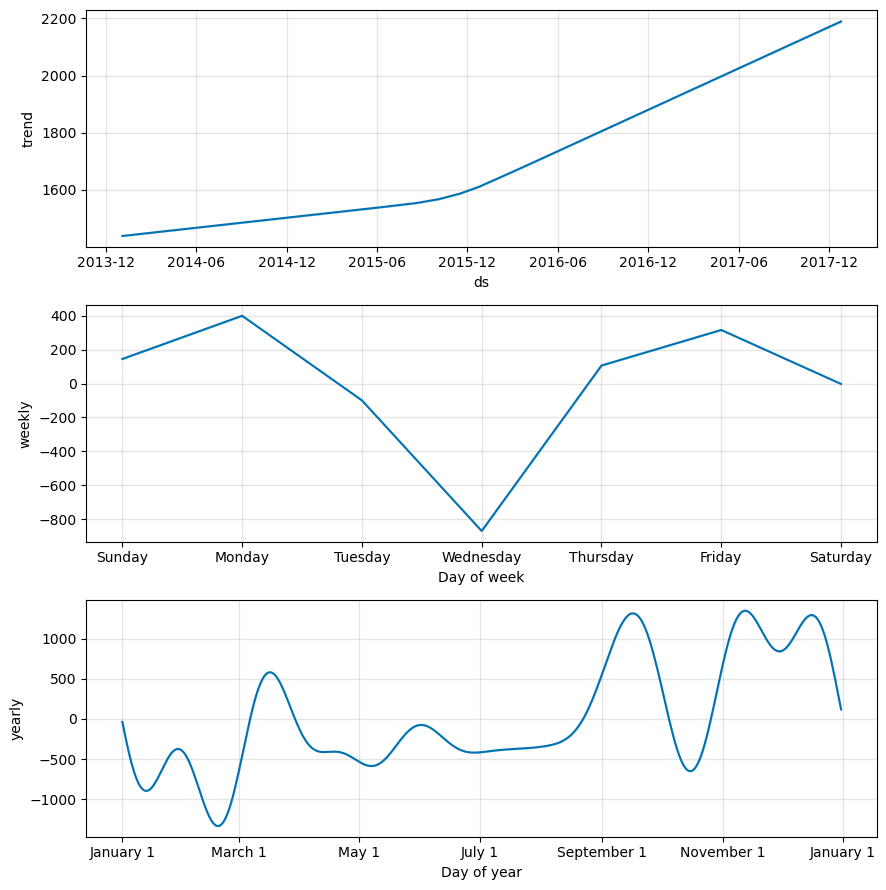

In [47]:
fig2 = model.plot_components(forecast)
plt.show()

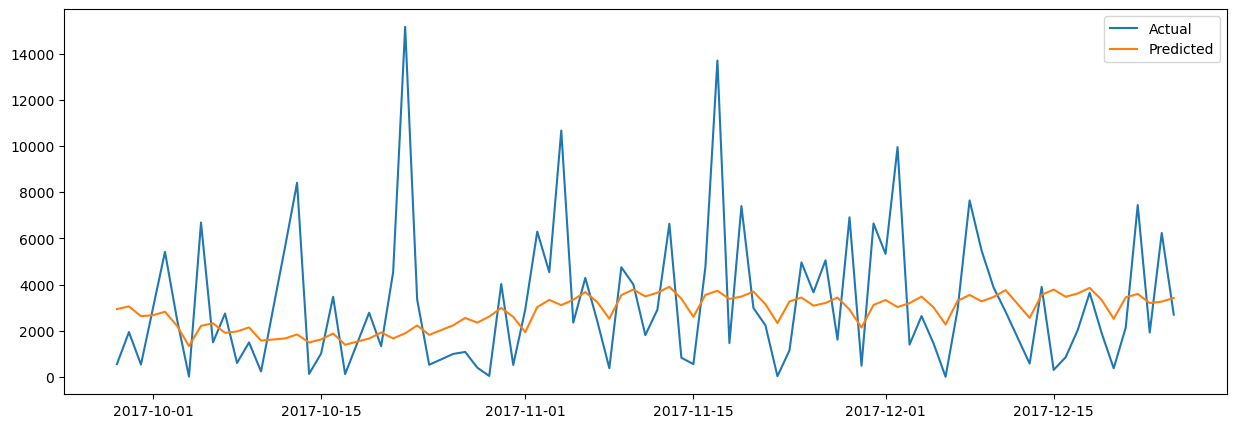

In [48]:
plt.figure(figsize=(15,5))

plt.plot(final_df['ds'], final_df['y'], label='Actual')

plt.plot(final_df['ds'], final_df['yhat'], label='Predicted')

plt.legend()

plt.show()

In [50]:
forecast.to_csv('../outputs/forecast.csv', index=False)

In [53]:
import joblib

joblib.dump(model, "../models/sales_forecast.pkl")

['../models/sales_forecast.pkl']

In [59]:
model = joblib.load("../models/sales_forecast.pkl")

In [63]:
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()

model = joblib.load("../models/sales_forecast.pkl")

@app.get("/forecast")

def forecast():

    future = model.make_future_dataframe(periods=30)

    forecast = model.predict(future)

    result = forecast[['ds', 'yhat']].tail(30)

    return result.to_dict()